# **Primary analysis on clinical embeddings**

In [22]:
%load_ext autoreload
%autoreload 2
import os, sys
import pandas as pd
import numpy as np
import pickle as pkl
import torch
import seaborn as sns
import matplotlib.pyplot as plt 
import subprocess

from foundation.clinical import pipeline_clinical

from gbmhackathon.data import MosaicDataset
from gbmhackathon.s3_loader import load_s3, write_s3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Generate clinical embedding with correct processing

In [23]:
# clinical_data = pipeline_clinical(verbose=True)
# write_s3(clinical_data, 'clinical_emb_V1', 'embedding_V1')

Preparing Data...
Imputing numerical features...
Scaling numerical features...
Multi Component Analysis..
Retrieving column contributions..
Imputing targets..
Scaling targets..
Object saved at s3://abstra-project-storage-lttemftb/1b75dc89-ad27-4a65-9e7f-877d1b4f36fc/embedding_V1/2025-03-30_14-23_clinical_emb_V1.pkl


In [3]:
# clinical_data['dataset'].keys()

### Load data

In [24]:
BUCKET_MOSAIC = "ABSTRA_DATASET_03bb30aa_16ed_4b89_913e_fe009db2aabd"
BUCKET_PROJECT = "ABSTRA_PROJECT_STORAGE_BUCKET"

def fetch_path(env_var_name):
    return os.path.expandvars(f"${env_var_name}")

S3_PATH_CLINICAL_EMB = fetch_path(BUCKET_PROJECT) + "embedding_V1/2025-03-30_14-23_clinical_emb_V1.pkl"
S3_PATH_MODALITIES_PER_SAMPLES = fetch_path(BUCKET_MOSAIC) + "Data availibility per modality per sample.csv"
S3_PATH_PROJECT = fetch_path(BUCKET_PROJECT)

In [25]:
clinical_dict = load_s3(S3_PATH_CLINICAL_EMB)

### Retrieve modalities per samples

In [26]:
#modality_per_sample = pd.read_csv(S3_PATH_MODALITIES_PER_SAMPLES)
#modality_per_sample.index = modality_per_sample['Hackathon_ID']
#modality_per_sample = modality_per_sample[[col for col in modality_per_sample.columns if col != 'Hackathon_ID']]
#modality_per_sample

In [27]:
# def get_missing(row):
#     columns = row.index
#     missing = []
#     for i in range(len(row)):
#         if row.iloc[i] == 'No':
#             missing.append(columns[i].split("_")[0])
#     return missing

# missing_mod = modality_per_sample.apply(get_missing, axis=1)

In [28]:
# dico_missing_mod = {idx:missing_mod.loc[idx] for idx in missing_mod.index if len(missing_mod.loc[idx]) != 6}

In [29]:
# dico_missing_mod

In [30]:
#import s3fs
#path = f"{S3_PATH_PROJECT}missing_mod_per_samples.pkl"
#fs = s3fs.S3FileSystem()
#with fs.open(path=path, mode = "wb") as f : 
#    pkl.dump(dico_missing_mod, f)

In [31]:
clinical_dict['dataset'].keys()

dict_keys(['id2row', 'cat_features', 'num_features', 'features', 'targets', 'mca_contributions', 'X', 'Y', 'imputed_Y', 'original_Y'])

In [32]:
clinical_dict['dataset']['features']

['age_at_diagnosis_years',
 'time_interval_sample_harvest_dearchival_years',
 'C0',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9']

### Analysis

In [33]:
id2row = clinical_dict['dataset']['id2row']
X = clinical_dict['dataset']['X']
Y = clinical_dict['dataset']['Y']
features = clinical_dict['dataset']['features']
targets = clinical_dict['dataset']['targets']
per_mod_contributions = clinical_dict['dataset']['mca_contributions']

In [34]:
X_df = pd.DataFrame(X.numpy(), columns=features, index=list(id2row.keys()))
Y_df = pd.DataFrame(Y.numpy(), columns=targets, index=list(id2row.keys()))
dataset = pd.concat([X_df, Y_df], axis=1)

### Correlations

Look at correlations between input features and target variables but also between input features themselves.

<Axes: >

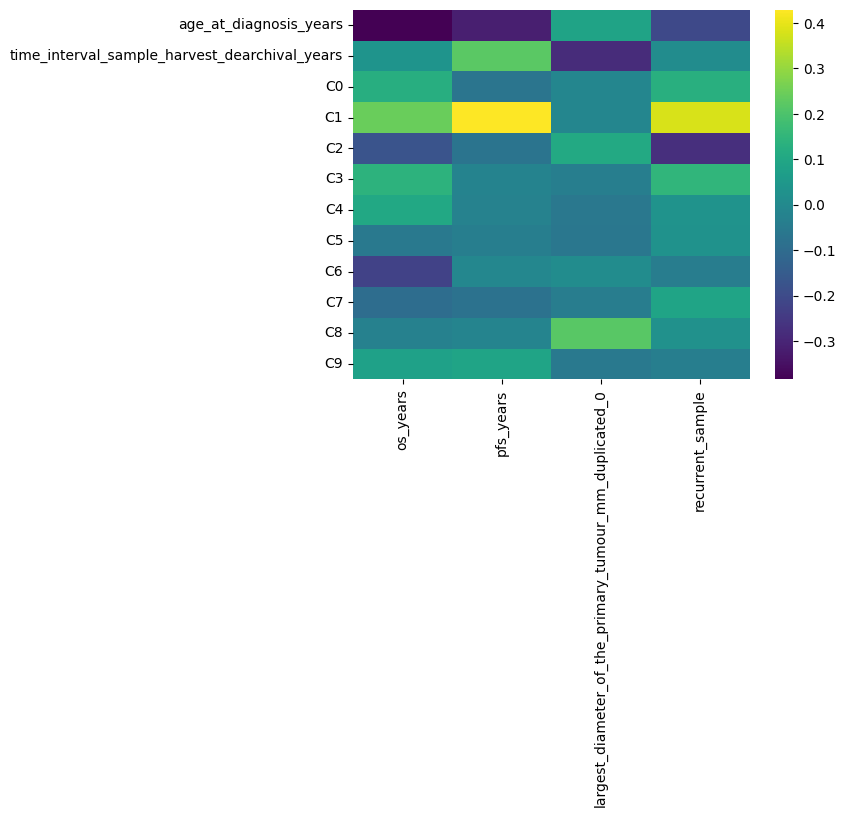

In [35]:
corr = dataset.corr()

sns.heatmap(corr[targets].loc[features], yticklabels=True, cmap='viridis')

Component 2 seems to be quite correlated to progression free years and recurrency.

Let's look at MCA contributions.

<Axes: ylabel='feature'>

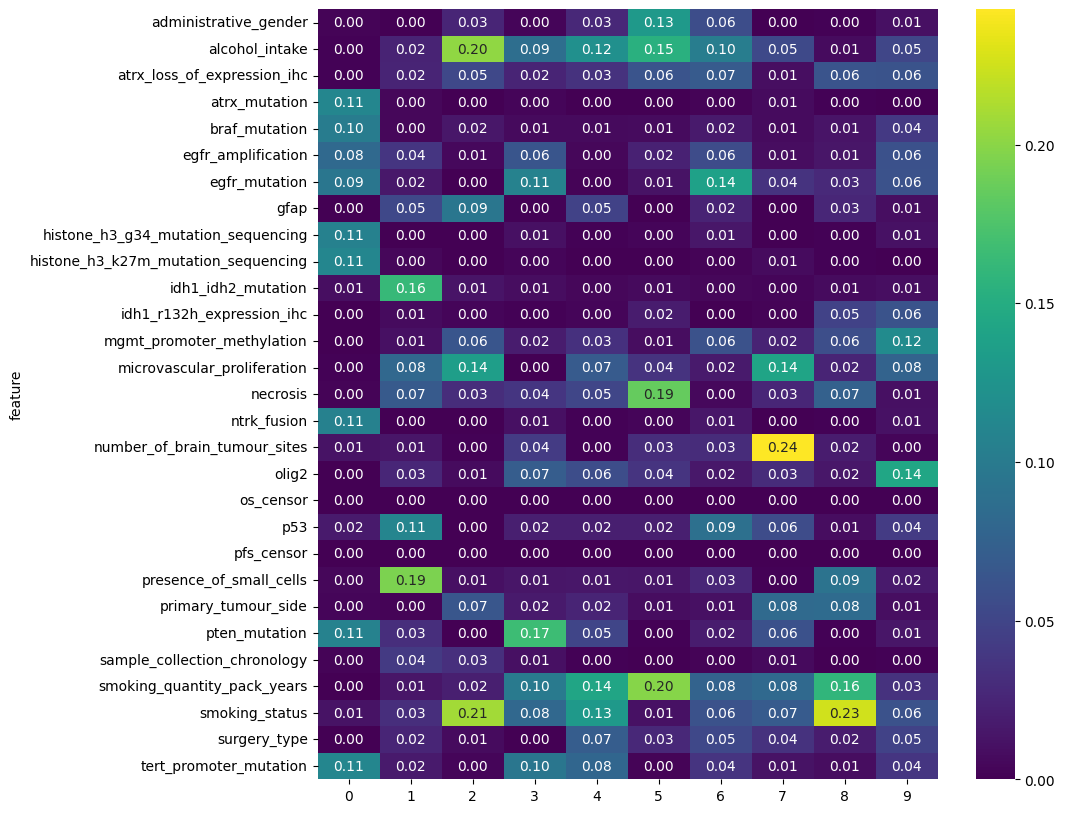

In [36]:
plt.figure(figsize=(10,10))
per_col_contributions = per_mod_contributions.groupby("feature").sum()
sns.heatmap(per_col_contributions, cmap='viridis', annot=True, fmt='.2f', yticklabels=True)

Interestingly, component 1 is mainly contributed by presence_of_small_cells, idh1_idh2_mutation and p53. Let's look more precisely.

In [42]:
per_mod_contributions[per_mod_contributions["feature"].isin(["presence_of_small_cells", "idh1_idh2_mutation", "p53"])]

,0,1,2,3,4,5,6,7,8,9,feature
presence_of_small_cells__No,0.000269,0.103355,0.005418,0.002654,0.005286,0.004327,0.000975,0.000798,0.001263,0.006643,presence_of_small_cells
presence_of_small_cells__Unk,0.001807,0.085895,0.001918,0.000069,0.000336,0.000111,0.010925,0.000116,0.033619,0.000673,presence_of_small_cells
presence_of_small_cells__Yes,0.001725,0.005585,0.003076,0.010585,0.009174,0.009336,0.013892,0.000973,0.057628,0.009702,presence_of_small_cells
p53__Negative,0.001543,0.047681,0.000038,0.004662,0.008571,0.006329,0.002157,0.012503,0.001166,0.002523,p53
p53__Positive,0.011490,0.000008,0.000123,0.014586,0.012216,0.000593,0.056543,0.039563,0.005978,0.012588,p53
p53__Unk,0.003246,0.062677,0.000314,0.001322,0.000003,0.013336,0.030120,0.003674,0.001181,0.027387,p53
idh1_idh2_mutation__No mutation,0.004359,0.078220,0.006388,0.003687,0.002169,0.002884,0.002084,0.001445,0.003612,0.004279,idh1_idh2_mutation
idh1_idh2_mutation__Unk,0.004677,0.083909,0.006853,0.003956,0.002326,0.003094,0.002236,0.001550,0.003875,0.004590,idh1_idh2_mutation


<Axes: >

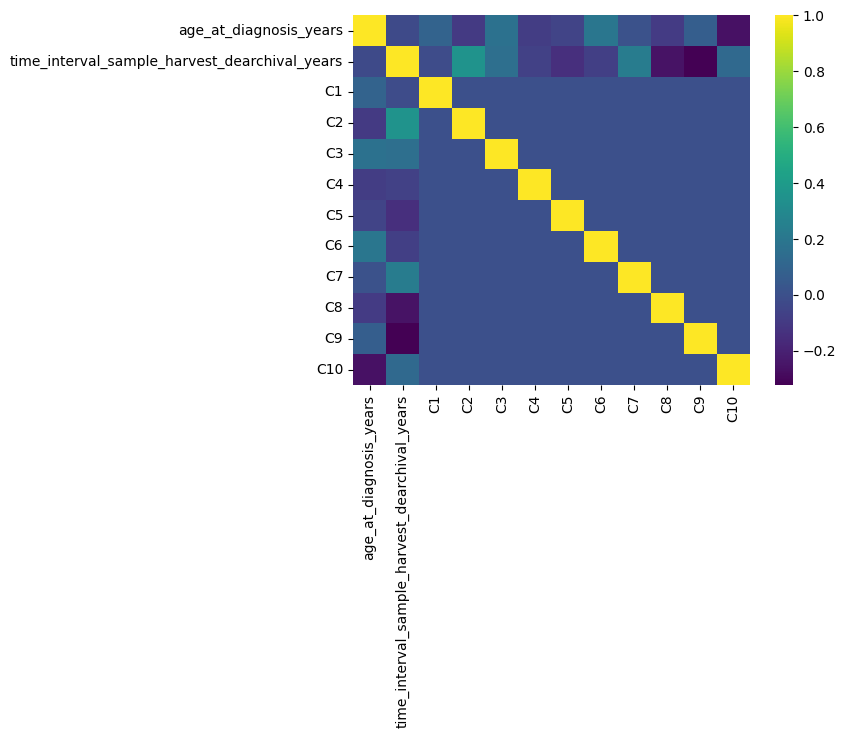

In [85]:
sns.heatmap(corr[features].loc[features], yticklabels=True, cmap='viridis')

### T-SNE

Look at patients using TSNE projection and color by target variables

### UMAP

Look at patients using UMAP projection and color by target variables